# Data Cleaning and EDA on Titanic Datasets

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
dataset = sns.load_dataset("titanic")
dataset.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


In [4]:
dataset.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
missing = pd.DataFrame({
    "Missing Values": dataset.isnull().sum(),
    "Percentage": (dataset.isnull().sum()/len(dataset))*100
})

missing = missing[missing["Missing Values"] > 0]

missing

,Missing Values,Percentage
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


In [14]:
dataset["age"] = dataset["age"].fillna(dataset["age"].median())

dataset["embarked"] = dataset["embarked"].fillna(dataset["embarked"].mode()[0])

dataset["embark_town"] = dataset["embark_town"].fillna(dataset["embark_town"].mode()[0])

dataset.drop(columns="deck", errors = "ignore" , inplace=True)

dataset.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [15]:
print("Duplicate Rows:", dataset.duplicated().sum())

dataset.drop_duplicates(inplace=True)

Duplicate Rows: 116


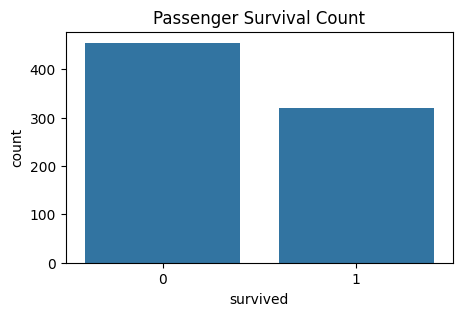

In [19]:
plt.figure(figsize=(5,3))

sns.countplot(x="survived", data=dataset)

plt.title("Passenger Survival Count")

plt.show()

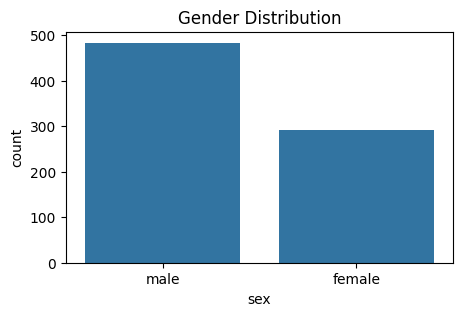

In [21]:
plt.figure(figsize=(5,3))

sns.countplot(x="sex", data=dataset)

plt.title("Gender Distribution")

plt.show()

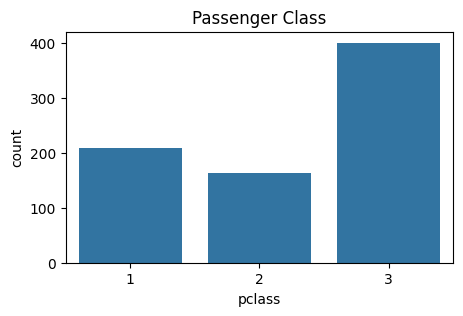

In [23]:
plt.figure(figsize=(5,3))

sns.countplot(x="pclass", data=dataset)

plt.title("Passenger Class")

plt.show()

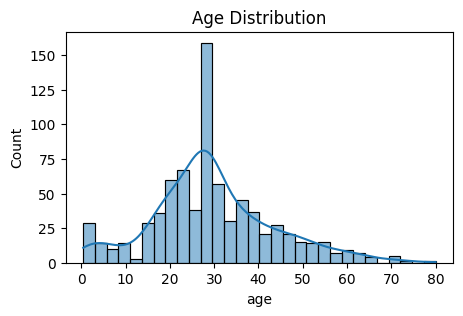

In [25]:
plt.figure(figsize=(5,3))

sns.histplot(dataset["age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

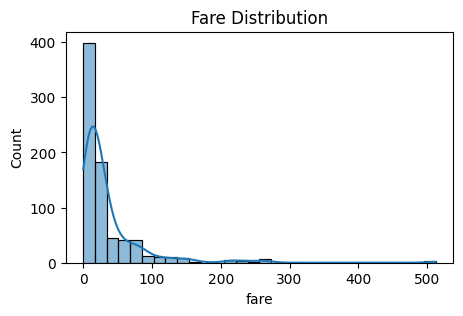

In [27]:
plt.figure(figsize=(5,3))

sns.histplot(dataset["fare"], bins=30, kde=True)

plt.title("Fare Distribution")

plt.show()

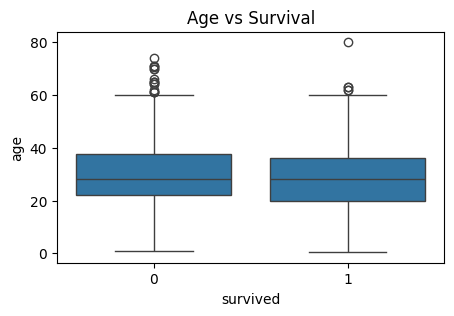

In [28]:
plt.figure(figsize=(5,3))

sns.boxplot(x="survived", y="age", data=dataset)

plt.title("Age vs Survival")

plt.show()

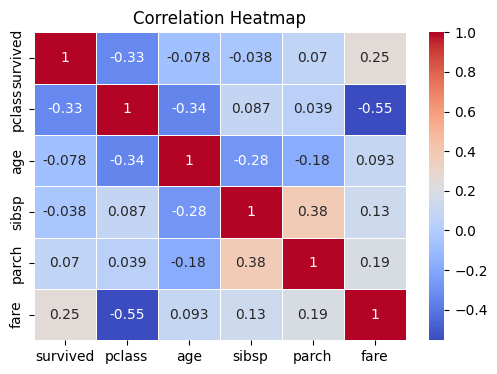

In [29]:
numeric_dataset = dataset.select_dtypes(include=np.number)

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_dataset.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

<Figure size 600x400 with 0 Axes>

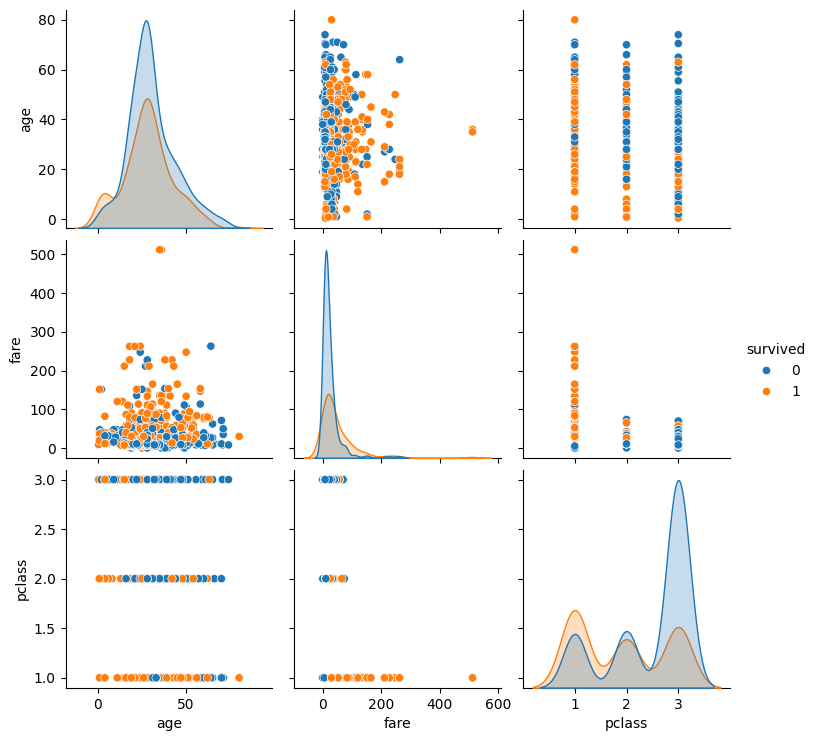

In [32]:
plt.figure(figsize=(6,4))

sns.pairplot(
    dataset[
        ["survived",
         "age",
         "fare",
         "pclass"]
    ],
    hue="survived"
)

plt.show()